[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TarannumAhmedNowshin/Automated-Essay-Scoring/blob/main/transformermodels/indicbert-large.ipynb)


# IndicBERT (AI4Bharat) — Automated Essay Scoring (large dataset)

Fine-tunes [`ai4bharat/indic-bert`](https://huggingface.co/ai4bharat/indic-bert)
as a **regression** model that predicts an essay score (0–10) from a
`Question` + `Answer` pair, trained on the **large** dataset (~1,408 graded scripts).

**Pipeline (next cell):**
1. Load and clean the data from `data/essays_large.csv`.
2. Build a Hugging Face `Dataset`, then tokenize (max length 512).
3. Split into train / validation / test (80 / 10 / 10).
4. Add a linear regression head on top of the `[CLS]` representation.
5. Fine-tune with early stopping, then report **RMSE**, **MAE**, and **R²**.

> Place the dataset in a local `data/` folder first — see the repo's
> [data/README.md](../data/README.md) for the expected columns.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


c:\Users\T2410207\Anaconda3\envs\aibharatfinal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset preview:
   FileName                                           Question  \
0         1  তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতায়  দেশ...   
1         2  তোমাকে পাওয়ার জন্য, হে স্বাধীনতা” কবিতায় দেশাত...   
2         3  তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা' কবিতায় দেশ...   
3         4  সমানুভূতি বলতে কী বোঝো? "পোস্টমাস্টার" গল্পে ক...   
4         5  ‘তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’  কবিতাটি ন...   

                                              Answer Marks  \
0  কবি শামসুর রাহমান নাগরিক কবি হিসেবে পরিচিত। তি...  8.75   
1  কবি শামসুর রহমানের (১৯২৯-২০০৬) কবিতায় সর্বদা স...   6.5   
2  তোমাকে পাওয়ার জন্যে, হে স্বাধীনতা’ কবিতাটি রচন...  8.75   
3  “পোস্টমাস্টার” রবীন্দ্রনাথ ঠাকুর (১৮৬১-১৯৪১) -...   8.5   
4  বাংলার মানুষ ১৯৭১ সালে জাতীয়তাবাদী চেতনায় উদ্ব...     8   

                                            feedback  
0                কাব্যগ্রন্থ ও কবিতার প্রকাশকাল নেই।  
1   কবি ও কবিতার নামে ভুল। অসংগতিপূর্ণ বাক্য। \r\n\r  
2  নিচু ক্লাসের জন্য লেখা রেফারেন্স হিসেবে ব্যবহ

Map: 100%|██████████| 1122/1122 [00:03<00:00, 322.50 examples/s]


Successfully tokenized train dataset.


...

Cleaned up folder: ./results


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: faltuthesis (faltuthesis-brac-university). Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Step,Training Loss,Validation Loss,Mse,Rmse,Mae,R2
20,55.347300,65.304550,65.304550,8.081123,8.044444,-109.377853
40,55.347300,64.651314,64.651314,8.040604,8.003698,-108.273750
60,61.707000,62.908726,62.908718,7.931502,7.894040,-105.328423
80,61.707000,57.791157,57.791157,7.602050,7.562990,-96.678703
100,53.188900,37.855034,37.855030,6.152644,6.104169,-62.982632
120,53.188900,23.417847,23.417843,4.839199,4.781125,-38.580879
140,53.188900,14.702342,14.702340,3.834363,3.773846,-23.849920
160,20.300000,9.442775,9.442774,3.072910,3.004133,-14.960192
180,20.300000,6.268340,6.268340,2.503665,2.428289,-9.594759
200,6.535200,4.452273,4.452273,2.110041,2.022279,-6.525239


Could not locate the best model at ./results\checkpoint-1560\pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.


True Marks vs. Predicted Marks:
True: 8.50, Predicted: 8.25
True: 7.50, Predicted: 8.27
True: 7.00, Predicted: 7.76
True: 7.50, Predicted: 8.05
True: 9.00, Predicted: 7.76
True: 9.00, Predicted: 8.31
True: 9.00, Predicted: 8.32
True: 7.00, Predicted: 8.17
True: 8.00, Predicted: 8.32
True: 8.50, Predicted: 8.32
True: 8.00, Predicted: 8.02
True: 8.00, Predicted: 8.32
True: 8.00, Predicted: 8.18
True: 8.50, Predicted: 7.53
True: 8.00, Predicted: 7.04
True: 9.00, Predicted: 8.31
True: 9.00, Predicted: 8.34
True: 8.00, Predicted: 8.31
True: 8.75, Predicted: 8.32
True: 8.50, Predicted: 8.23
True: 7.50, Predicted: 7.32
True: 7.50, Predicted: 7.50
True: 8.75, Predicted: 7.80
True: 8.75, Predicted: 8.30
True: 7.50, Predicted: 8.33
True: 8.50, Predicted: 8.03
True: 8.50, Predicted: 8.28
True: 9.00, Predicted: 8.16
True: 8.00, Predicted: 8.14
True: 7.75, Predicted: 7.94
True: 7.50, Predicted: 8.22
True: 7.50, Predicted: 7.58
True: 7.50, Predicted: 7.67
True: 7.50, Predicted: 8.04
True: 7.75, Pred

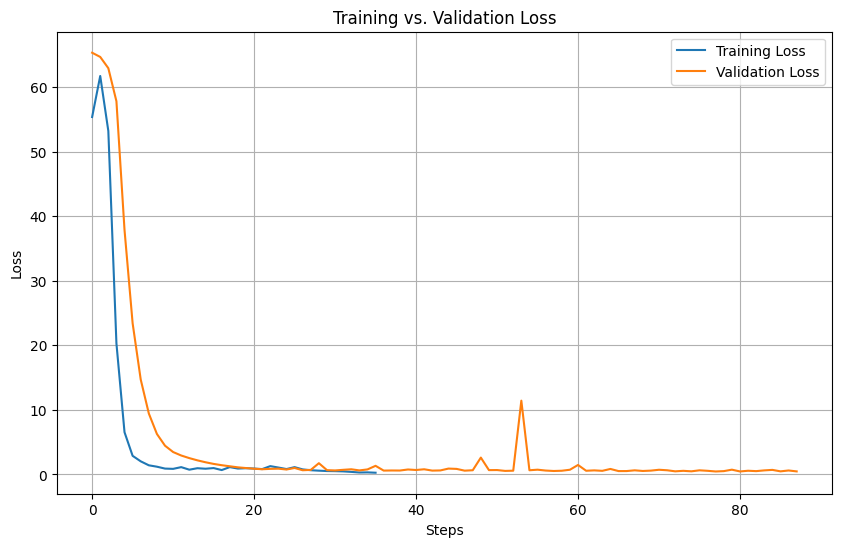

In [ ]:
# Optional: install dependencies (or use the repo's requirements.txt)
%pip install -q transformers datasets pyarrow matplotlib

# Import necessary libraries
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from transformers import AutoTokenizer, TrainingArguments, AutoModel
from datasets import Dataset
from transformers import TrainerCallback, Trainer, EarlyStoppingCallback
import os
import matplotlib.pyplot as plt

# Function to make tensors contiguous
def make_tensors_contiguous(state_dict):
    return {k: v.contiguous() for k, v in state_dict.items()}

# CustomTrainer class with modified _save method
class CustomTrainer(Trainer):
    def _save(self, output_dir: str, state_dict=None):
        if state_dict is None:
            state_dict = make_tensors_contiguous(self.model.state_dict())
        torch.save(state_dict, os.path.join(output_dir, "pytorch_model.bin"))

# Load the dataset (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_large.csv")
tarc_df = pd.read_csv(path)

# Debug: Print the first few rows and check the columns
print("Dataset preview:")
print(tarc_df.head())
print("Columns:", tarc_df.columns)

df = tarc_df.copy()

# Drop rows where 'Answer' or 'Marks' is missing
df = df[['Question', 'Answer', 'Marks']].dropna(subset=['Answer', 'Marks'])

# Ensure 'Marks' column is numeric
df['Marks'] = pd.to_numeric(df['Marks'], errors='coerce')
df = df.dropna(subset=['Marks'])

# Combine 'Question' and 'Answer' into one column
df['essays'] = "Question: " + df['Question'].astype(str) + " Answer: " + df['Answer'].astype(str)
df['scores'] = df['Marks']

# Validate combined dataset
print("Final dataset preview:")
print(df[['essays', 'scores']].head())

# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(df[['essays', 'scores']])

# Split dataset into train, validation, and test sets
split_dataset = dataset.train_test_split(test_size=0.2)
train_dataset = split_dataset['train']
remaining_dataset = split_dataset['test']

# Further split the remaining dataset into validation and test sets
split_remaining = remaining_dataset.train_test_split(test_size=0.5)
val_dataset = split_remaining['train']
test_dataset = split_remaining['test']

# Define tokenizer and model
model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False, trust_remote_code=True)

# Tokenize the dataset
def tokenize_function(examples):
    return tokenizer(examples['essays'], truncation=True, padding='max_length', max_length=512)

# Tokenize datasets with error handling
def safe_tokenize(dataset, name):
    try:
        tokenized = dataset.map(tokenize_function, batched=True)
        print(f"Successfully tokenized {name} dataset.")
        return tokenized
    except Exception as e:
        print(f"Error during tokenization of {name} dataset: {e}")
        raise

tokenized_train = safe_tokenize(train_dataset, "train")
tokenized_val = safe_tokenize(val_dataset, "validation")
tokenized_test = safe_tokenize(test_dataset, "test")

# Rename 'scores' to 'labels' as expected by Trainer
tokenized_train = tokenized_train.rename_column("scores", "labels")
tokenized_val = tokenized_val.rename_column("scores", "labels")
tokenized_test = tokenized_test.rename_column("scores", "labels")

# Set PyTorch format
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_val.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Model setup for regression
class BertForRegression(torch.nn.Module):
    def __init__(self, model_name):
        super(BertForRegression, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.regressor = torch.nn.Linear(self.bert.config.hidden_size, 1)  # Single output for regression

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :].contiguous()
        logits = self.regressor(pooled_output).view(-1).contiguous()
        if labels is not None:
            loss_fct = torch.nn.MSELoss()
            loss = loss_fct(logits, labels.view(-1))
            return loss, logits
        return logits

# Callback for tracking overfitting
class OverfittingCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.eval_losses.append(logs["eval_loss"])

    def plot_losses(self):
        if self.train_losses and self.eval_losses:
            plt.figure(figsize=(10, 6))
            plt.plot(self.train_losses, label="Training Loss")
            plt.plot(self.eval_losses, label="Validation Loss")
            plt.title("Training vs. Validation Loss")
            plt.xlabel("Steps")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid()
            plt.show()

# Initialize the callback
overfitting_callback = OverfittingCallback()

# Initialize model
model = BertForRegression(model_name)

# Move model to device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Metric computation
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.squeeze()
    mse = mean_squared_error(labels, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(labels, predictions)
    r2 = r2_score(labels, predictions)
    return {
        "eval_mse": mse,
        "eval_rmse": rmse,
        "eval_mae": mae,
        "eval_r2": r2,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=30,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=1000,
    gradient_accumulation_steps=4,
    lr_scheduler_type="cosine",
    save_steps=2000,
    save_total_limit=2,
    logging_dir="./logs",
    logging_steps=50,
    evaluation_strategy="steps",
    eval_steps=20,
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_rmse",
    greater_is_better=False,
    max_grad_norm=1.0,
)

# Define EarlyStoppingCallback
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=10,  # Stop after 10 evaluations without improvement
    early_stopping_threshold=0.001  # Minimum change in metric to qualify as improvement
)

# Clean up the 'results' folder
import shutil
folder = "./results"
try:
    shutil.rmtree(folder)  # Deletes the folder and all its contents
    print(f"Cleaned up folder: {folder}")
except FileNotFoundError:
    print(f"Folder does not exist: {folder}")
except Exception as e:
    print(f"Error while cleaning folder: {e}")

    
# Trainer initialization
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    callbacks=[overfitting_callback, early_stopping],  # Include early stopping
)

# Train the model
trainer.train()

# Evaluate on validation dataset
results = trainer.predict(tokenized_val)

# Extract predictions and labels
predictions = results.predictions.squeeze()
labels = results.label_ids

# Print true vs. predicted marks
print("True Marks vs. Predicted Marks:")
for true, pred in zip(labels, predictions):
    print(f"True: {true:.2f}, Predicted: {pred:.2f}")

# Plot training vs. validation loss
overfitting_callback.plot_losses()


## Evaluation and visualization

Metrics and diagnostic plots (true vs. predicted, residuals, absolute errors)
computed on the train / validation / test splits.


In [2]:
# After training, evaluate on the train, validation, and test datasets

# Evaluate on training set
train_results = trainer.predict(tokenized_train)
train_predictions = train_results.predictions.squeeze()
train_labels = train_results.label_ids

# Compute metrics for the train set
train_mse = mean_squared_error(train_labels, train_predictions)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(train_labels, train_predictions)
train_r2 = r2_score(train_labels, train_predictions)

# Print the results for the train set
print(f"Train Set - RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")

# Evaluate on validation set
val_results = trainer.predict(tokenized_val)
val_predictions = val_results.predictions.squeeze()
val_labels = val_results.label_ids

# Compute metrics for the validation set
val_mse = mean_squared_error(val_labels, val_predictions)
val_rmse = np.sqrt(val_mse)
val_mae = mean_absolute_error(val_labels, val_predictions)
val_r2 = r2_score(val_labels, val_predictions)

# Print the results for the validation set
print(f"Validation Set - RMSE: {val_rmse:.4f}, MAE: {val_mae:.4f}, R²: {val_r2:.4f}")

# Evaluate on test set
test_results = trainer.predict(tokenized_test)
test_predictions = test_results.predictions.squeeze()
test_labels = test_results.label_ids

# Compute metrics for the test set
test_mse = mean_squared_error(test_labels, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_labels, test_predictions)
test_r2 = r2_score(test_labels, test_predictions)

# Print the results for the test set
print(f"Test Set - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")


Train Set - RMSE: 0.4835, MAE: 0.3598, R²: 0.7468


Validation Set - RMSE: 0.6879, MAE: 0.4704, R²: 0.2001


Test Set - RMSE: 0.7237, MAE: 0.5047, R²: 0.2527


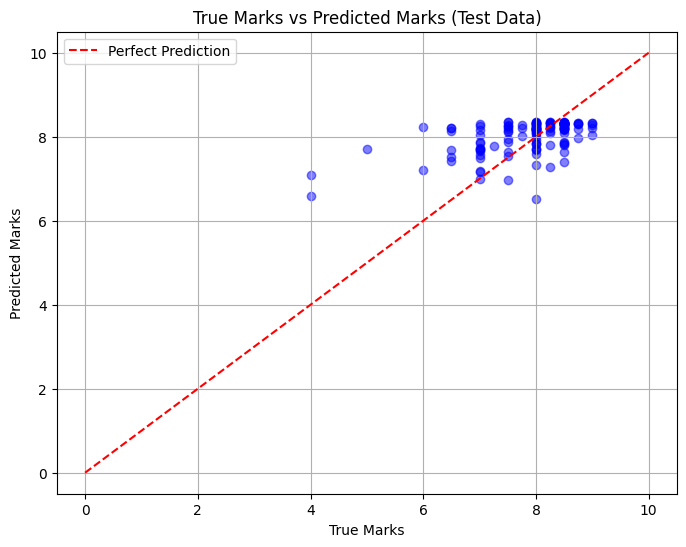

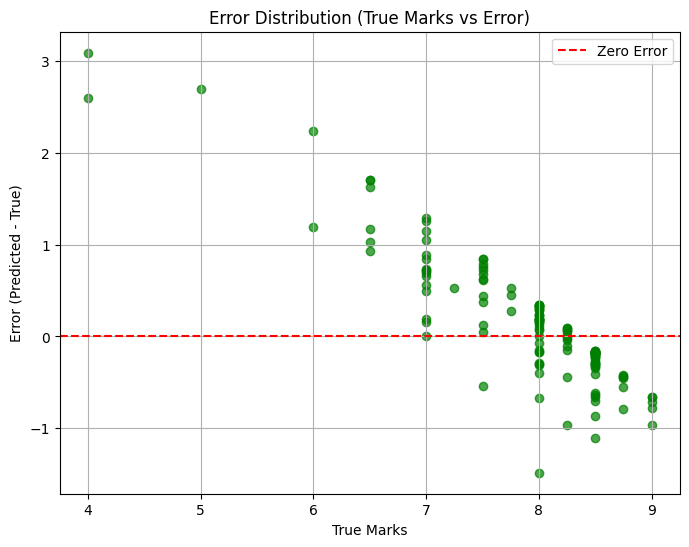

In [4]:
# Evaluate on the test dataset
test_results = trainer.predict(tokenized_test)

# Extract predictions and labels
test_predictions = test_results.predictions.squeeze()
test_labels = test_results.label_ids

# 1. True vs Predicted Marks Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(test_labels, test_predictions, color='blue', alpha=0.5)
plt.plot([0, 10], [0, 10], 'r--', label="Perfect Prediction")  # Diagonal line for perfect prediction
plt.title("True Marks vs Predicted Marks (Test Data)")
plt.xlabel("True Marks")
plt.ylabel("Predicted Marks")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(test_labels, errors, color='green', alpha=0.7)
plt.axhline(0, color='r', linestyle='--', label="Zero Error")  # Horizontal line at zero error
plt.title("Error Distribution (True Marks vs Error)")
plt.xlabel("True Marks")
plt.ylabel("Error (Predicted - True)")
plt.legend()
plt.grid(True)
plt.show()
